In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA

In [4]:
df.shape

(1338, 7)

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

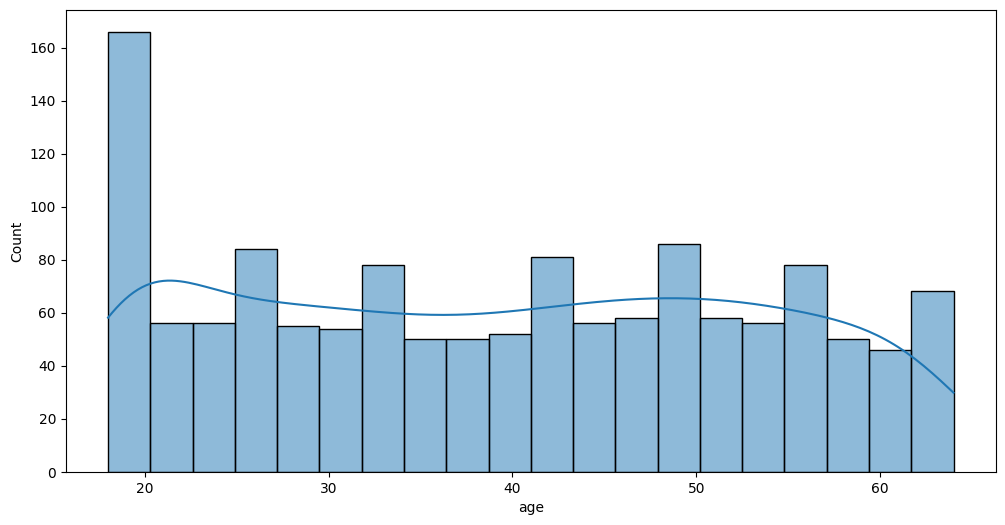

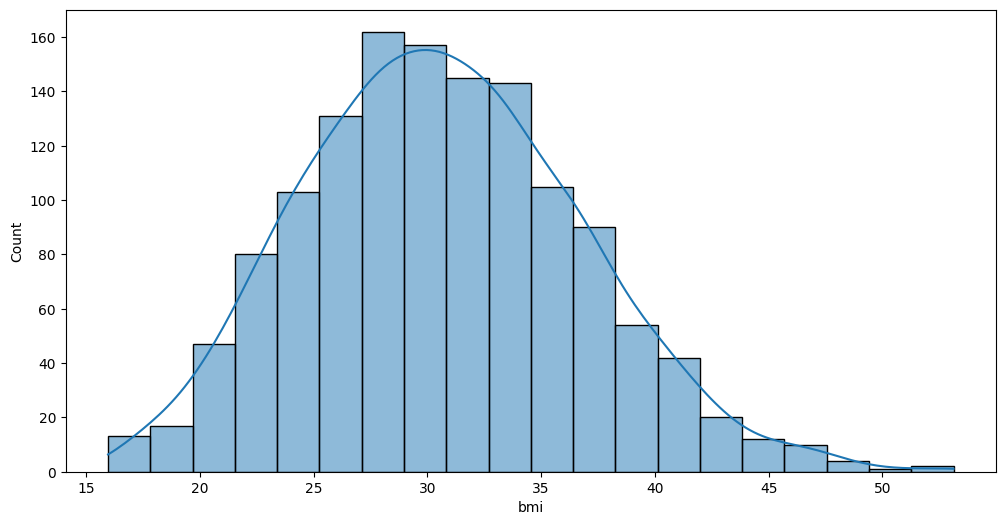

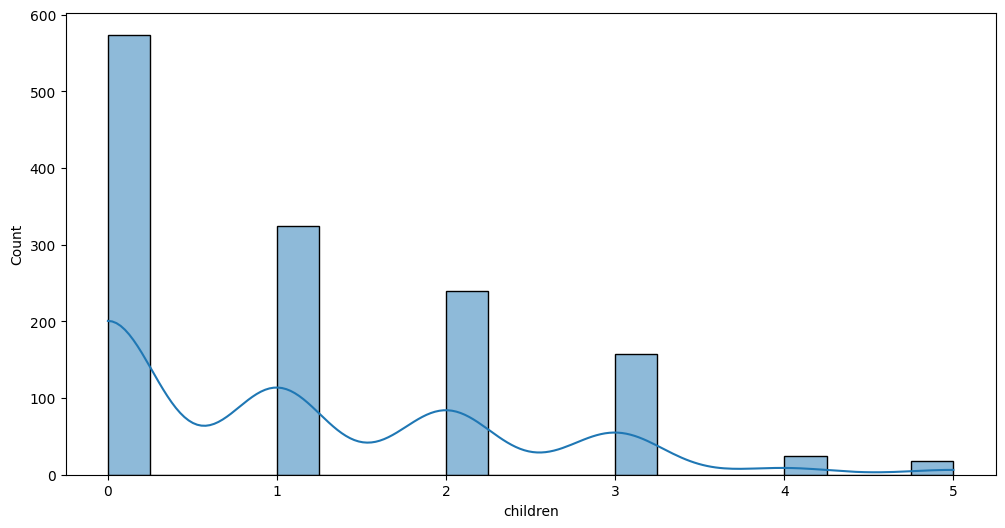

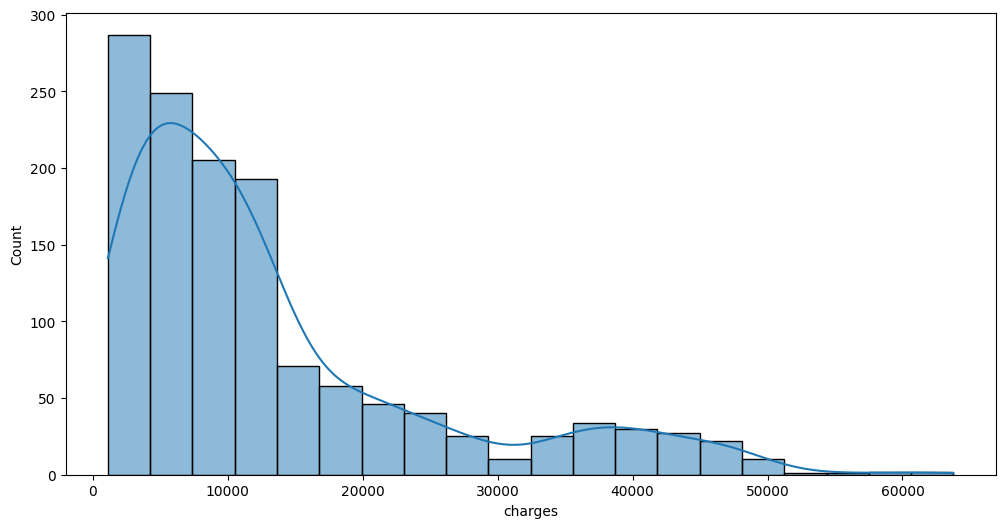

In [10]:
numeric_columns = ['age','bmi','children','charges']
for col in numeric_columns:
    plt.figure(figsize=(12,6))
    sns.histplot(df[col],kde = True, bins=20)


<Axes: xlabel='children', ylabel='count'>

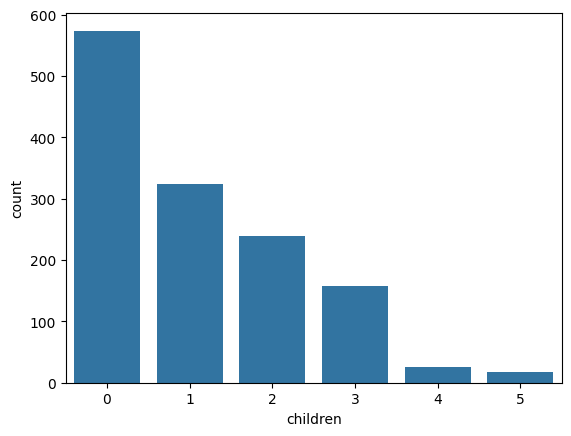

In [11]:
sns.countplot(x= df['children'])

<Axes: xlabel='sex', ylabel='count'>

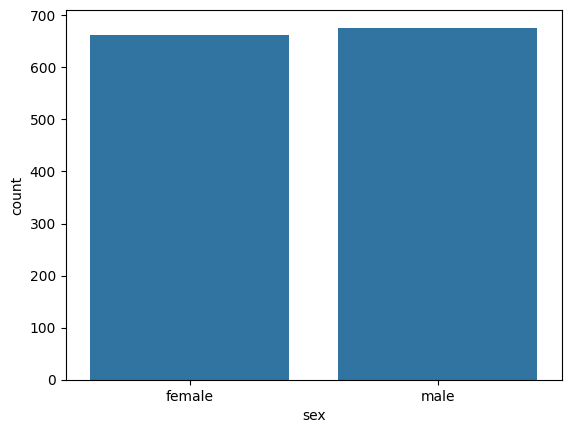

In [12]:
sns.countplot(x='sex',data=df)

<Axes: xlabel='smoker', ylabel='count'>

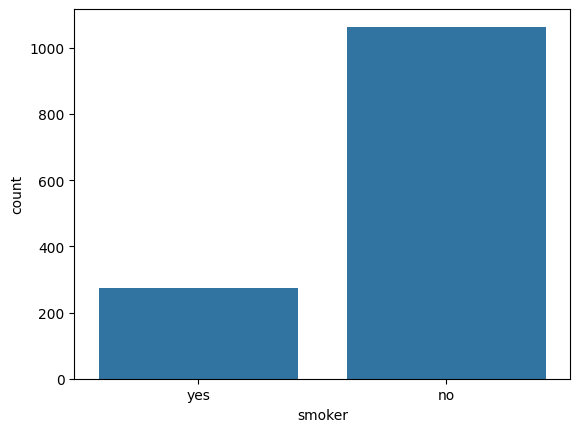

In [13]:
sns.countplot(x = df['smoker'])

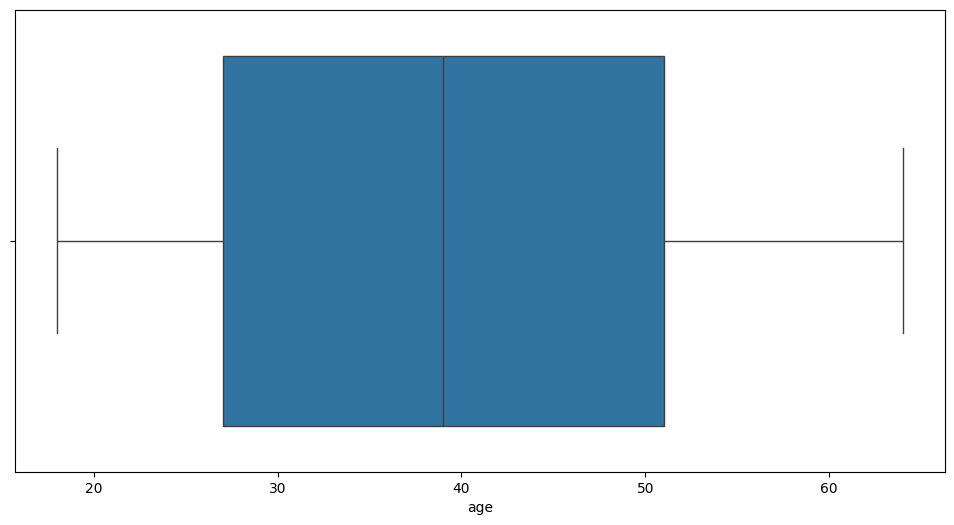

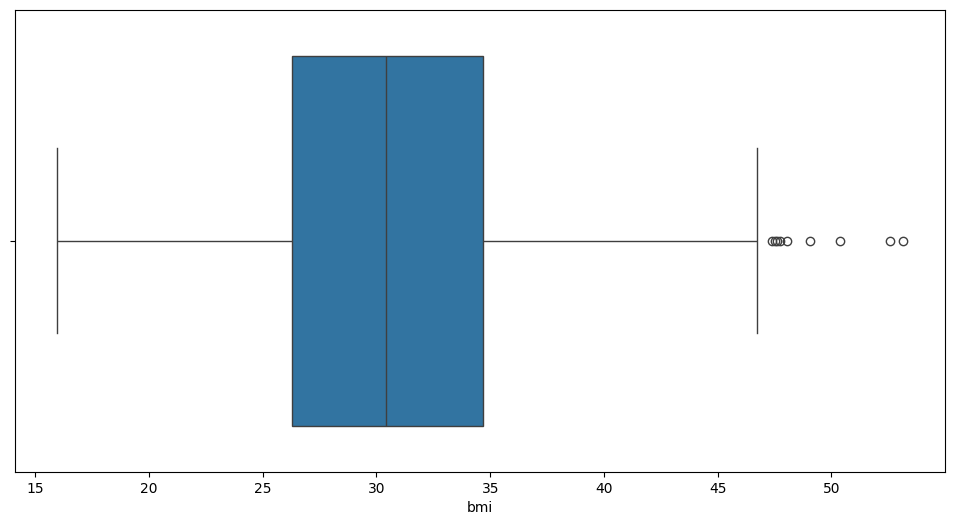

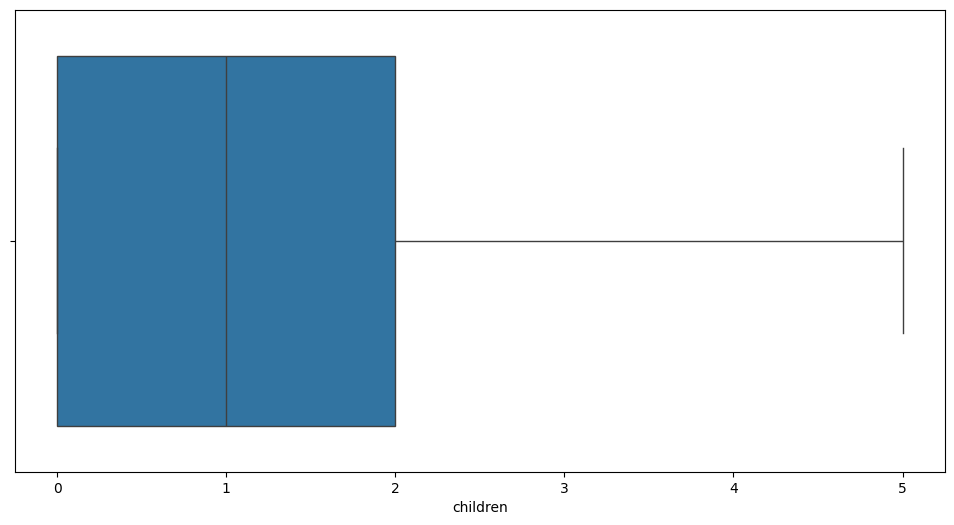

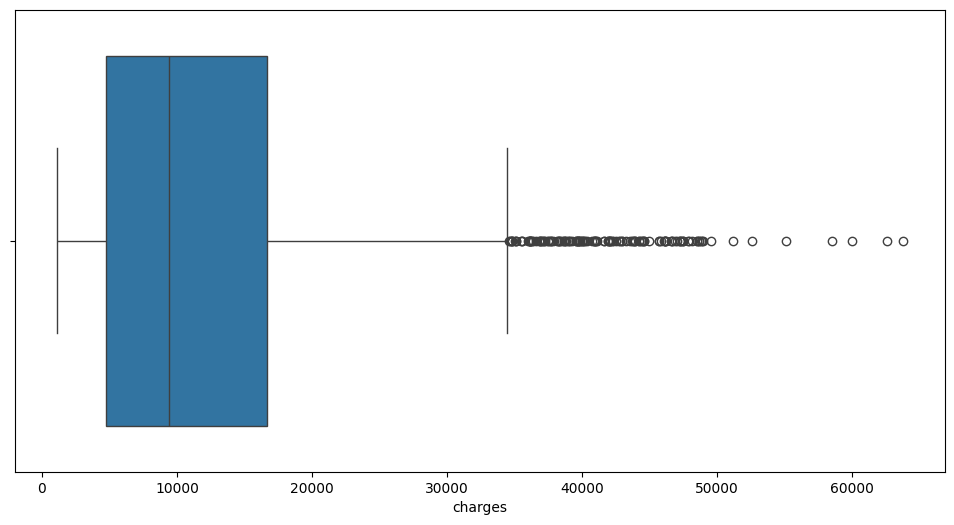

In [14]:
for col in numeric_columns:
    plt.figure(figsize=(12,6))
    sns.boxplot(x=df[col])

<Axes: >

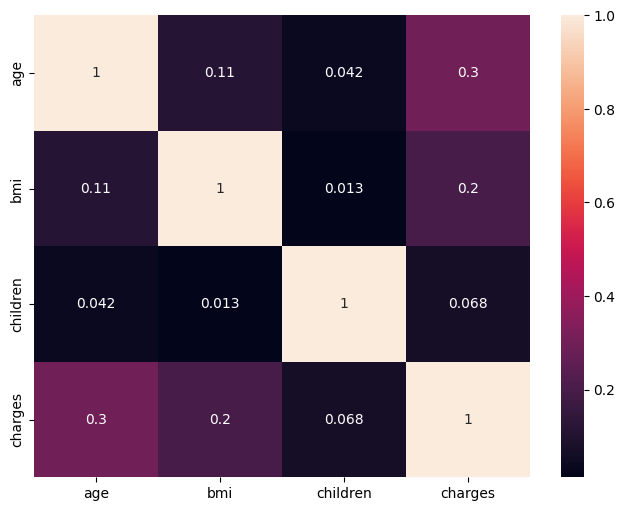

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Date cleaning and processing

In [16]:
df_cleaned = df.copy()

In [17]:
df_cleaned.drop_duplicates(inplace=True)

In [18]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [19]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [20]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [21]:
df_cleaned['sex'] = df_cleaned['sex'].map({
    "male":0,
    "female":1
})

In [22]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [23]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [24]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({
    "yes":1,
    "no":0
})

In [25]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [26]:
df_cleaned.rename(columns={
    "sex" : "is_female", 
    "smoker" : "is_smoker"
},inplace=True)

In [27]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [28]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [29]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)

In [30]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False
1334,18,1,31.920,0,0,2205.98080,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,True


In [31]:
df_cleaned =df_cleaned.astype(int)

In [32]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


# Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

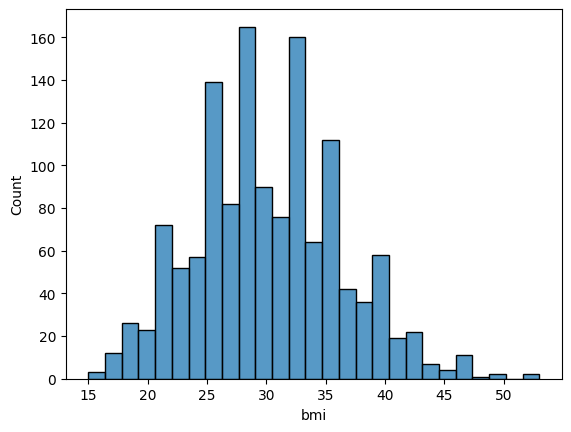

In [33]:
sns.histplot(df_cleaned['bmi'])

In [34]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins = [0, 18.5, 25, 30, float('inf')],
    labels = ['underwight','normal','overweight','obese']
)

In [35]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,overweight
1334,18,1,31,0,0,2205,0,0,0,obese
1335,18,1,36,0,0,1629,0,1,0,obese
1336,21,1,25,0,0,2007,0,0,1,normal


In [36]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)

In [37]:
df_cleaned = df_cleaned.astype(int)

In [38]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,1,0
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,1,0,0


In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols = ['age','bmi','children']
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])



In [40]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [41]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      1337 non-null   float64
 1   is_female                1337 non-null   int64  
 2   bmi                      1337 non-null   float64
 3   children                 1337 non-null   float64
 4   is_smoker                1337 non-null   int64  
 5   charges                  1337 non-null   int64  
 6   region_northwest         1337 non-null   int64  
 7   region_southeast         1337 non-null   int64  
 8   region_southwest         1337 non-null   int64  
 9   bmi_category_normal      1337 non-null   int64  
 10  bmi_category_overweight  1337 non-null   int64  
 11  bmi_category_obese       1337 non-null   int64  
dtypes: float64(3), int64(9)
memory usage: 135.8 KB


In [42]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'],
      dtype='str')

In [43]:
from scipy.stats import pearsonr

In [44]:
selected_features = ['age', 'bmi', 'children', 'is_female', 'is_smoker',
           'region_northwest', 'region_southeast', 'region_southwest',
           'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese']
correlations = {
    feature: pearsonr(df_cleaned[feature] , df_cleaned['charges'])[0]
    for feature in selected_features
}

In [45]:
corr_df = pd.DataFrame(list(correlations.items()),
                       columns=['feature', 'correlation'])
corr_df = corr_df.sort_values(by='correlation', ascending=False)


In [46]:
corr_df

,feature,correlation
4,is_smoker,0.787234
0,age,0.298309
1,bmi,0.196236
10,bmi_category_obese,0.189515
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_female,-0.058046
9,bmi_category_overweight,-0.081555


In [47]:
from scipy.stats import chi2_contingency


In [48]:
df_cleaned['charges_category'] = pd.qcut(
    df_cleaned['charges'],
    q=4,
    labels=['low', 'medium_low', 'medium_high', 'high']
)

In [49]:
categorical_features = [
    'is_female',
    'is_smoker',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'bmi_category_normal',
    'bmi_category_overweight',
    'bmi_category_obese'
]

In [50]:
alpha = 0.05   # significance level

results = []

for feature in categorical_features:
    
    # contingency table
    table = pd.crosstab(df_cleaned[feature], df_cleaned['charges_category'])
    
    # chi-square test
    chi2, p, dof, expected = chi2_contingency(table)
    
    # decision rule
    if p < alpha:
        decision = "Reject H0 (Significant relationship)"
    else:
        decision = "Fail to reject H0 (No significant relationship)"
    
    results.append([feature, chi2, p, decision])

In [51]:
chi_df = pd.DataFrame(
    results,
    columns=['feature', 'chi2_stat', 'p_value', 'decision']
)

In [52]:
chi_df = chi_df.sort_values(by='p_value')

In [53]:
chi_df

,feature,chi2_stat,p_value,decision
1,is_smoker,848.219178,1.507478e-183,Reject H0 (Significant relationship)
3,region_southeast,15.998167,1.134966e-03,Reject H0 (Significant relationship)
0,is_female,10.258784,1.648974e-02,Reject H0 (Significant relationship)
7,bmi_category_obese,9.737965,2.093002e-02,Reject H0 (Significant relationship)
4,region_southwest,5.091893,1.651906e-01,Fail to reject H0 (No significant relationship)
5,bmi_category_normal,4.771699,1.892983e-01,Fail to reject H0 (No significant relationship)
6,bmi_category_overweight,4.450807,2.167204e-01,Fail to reject H0 (No significant relationship)
2,region_northwest,1.134240,7.688154e-01,Fail to reject H0 (No significant relationship)


In [54]:
final_df = df_cleaned[[
    'age',
    'bmi',
    'children',
    'is_female',
    'is_smoker',
    'charges',
    'region_southeast',
    'bmi_category_obese'
]]


In [55]:
final_df

,age,bmi,children,is_female,is_smoker,charges,region_southeast,bmi_category_obese
0,-1.440418,-0.517949,-0.909234,1,1,16884,0,0
1,-1.511647,0.462463,-0.079442,0,0,1725,1,1
2,-0.799350,0.462463,1.580143,0,0,4449,1,1
3,-0.443201,-1.334960,-0.909234,0,0,21984,0,0
4,-0.514431,-0.354547,-0.909234,0,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,-0.027743,1.580143,0,0,10600,0,0
1334,-1.511647,0.135659,-0.909234,1,0,2205,0,1
1335,-1.511647,0.952670,-0.909234,1,0,1629,1,1
1336,-1.297958,-0.844753,-0.909234,1,0,2007,0,0
